# Acces S1 data at ASF DAAC on s3

`OPERA S1 RTC` at ASF DAAC AWS buckets 

Paul Montesano, PhD

 - Here is a simple notebook to stitch together OPERA RTC bursts.
https://nbviewer.org/github/OPERA-Cal-Val/OPERA_Applications/blob/main/RTC/notebooks/RTC_notebook.ipynb  
 - You can search for data availability here:
https://search.asf.alaska.edu/#/?dataset=OPERA-S1  
 - https://sentinel1.asf.alaska.edu/s3credentialsREADME  
 - https://notebooks.gesis.org/binder/jupyter/user/asfhyp3-tutorials-qyxt87m3/doc/tree/opera_RTC_mosaicing.ipynb  
 - Hyp3: https://nbviewer.org/github/ASFHyP3/hyp3-docs/blob/main/docs/tutorials/new-rtc-jobs.ipynb

#### Note:  
 - seems like `OPERA S1 L2 RTC` is only available from Oct 2023 onward?? https://doi.org/10.5067/SNWG/OPERA_L2_RTC-S1_V1
 - Hyp3 processing software lets us process results from ASF search to take SLC to RTC

In [1]:
from mpl_toolkits.basemap import Basemap

In [4]:
pip install -U contextily

Note: you may need to restart the kernel to use updated packages.


In [5]:
import s3fs
import os
import boto3
import pandas as pd
import geopandas as gpd
import sys
sys.path.append('/projects/code/icesat2_boreal/lib')
sys.path.append('/projects/code/geoscitools')
import footprintlib
import maplib
import CovariateUtils

import rasterio
import contextily as ctx
import requests
import glob

import rasterio as rio
from rasterio.windows import Window

## Access to sample data?

In [6]:
# https://nbviewer.org/github/OPERA-Cal-Val/OPERA_Applications/blob/main/RTC/notebooks/RTC_notebook.ipynb

In [7]:
import os
os.environ["AWS_NO_SIGN_REQUEST"] = "YES"

In [8]:
s3 = s3fs.S3FileSystem(anon=True)
# bad - takes forever
#cog_fn_list = s3.glob('s3://opera-pst-rs-pop1/products/RTC_S1/**/*.tif')

## Access to EarthData s3 bucket  --> TODO - access always denied?

https://github.com/nasa/EMIT-Data-Resources/blob/main/python/how-tos/How_to_Direct_S3_Access.ipynb

In [9]:
s3_cred_endpoint = {
    'podaac':'https://archive.podaac.earthdata.nasa.gov/s3credentials',
    'gesdisc': 'https://data.gesdisc.earthdata.nasa.gov/s3credentials',
    'lpdaac':'https://data.lpdaac.earthdatacloud.nasa.gov/s3credentials',
    'ornldaac': 'https://data.ornldaac.earthdata.nasa.gov/s3credentials',
    'ghrcdaac': 'https://data.ghrc.earthdata.nasa.gov/s3credentials',
    #'asfdaac': 'https://sentinel1.asf.alaska.edu/s3credentials',
    'asfdaac': 'https://cumulus.asf.alaska.edu/s3credentials'
}

In [10]:
# Define Function 
def get_temp_creds(provider):
    return requests.get(s3_cred_endpoint[provider]).json()

### Datasets at EarthDataCloud

In [29]:
# Get Credentials
temp_creds_req = get_temp_creds('asfdaac')

# Pass Authentication to s3fs
s3_asf= s3fs.S3FileSystem(anon=False, key=temp_creds_req['accessKeyId'], secret=temp_creds_req['secretAccessKey'], token=temp_creds_req['sessionToken'])

ASF_AWS_DATA_DICT_LIST = [
                    {
                'AWS_SESSION':    s3_asf,
                'REFERENCE':     '',
                'BUCKET' :       'opera-pst-rs-pop1/products/RTC_S1', #'asf-cumulus-prod-opera-products/OPERA_L2_RTC-S1', 
                'FILES_LIST':     None,
                'RASTER_BUCKET': 'opera-pst-rs-pop1/products/RTC_S1', #'asf-cumulus-prod-opera-products/OPERA_L2_RTC-S1', 
                'SEARCHKEY':     '**/**',
                'SEARCHEXT':     '.tif',
                'RASTER_LIST':    None
                },

]

In [33]:
# This is a bad idea b/c too much data
# s3_asf.ls('s3://asf-cumulus-prod-opera-products/OPERA_L2_RTC-S1')

# Need to do a maap search at the cmr endpoint using collection concept ID for OPERA S1 RTC data for a spatial/temporal extent

In [35]:
from maap.maap import MAAP
maap = MAAP()

In [57]:
OPERA_S1_RTC_CONCEPTID = 'C2777436413-ASF' #https://cmr.earthdata.nasa.gov/search/concepts/C2777436413-ASF.html

In [41]:
OPERA_collections = maap.searchCollection(
    #short_name='S1',
    concept_id=OPERA_S1_RTC_CONCEPTID, 
    cmr_host='cmr.earthdata.nasa.gov',
    cloud_hosted="true"
)
len(OPERA_collections)

1

In [47]:
import sys
sys.path.append('/projects/code/icesat2_boreal/lib')
import CovariateUtils
from mosaiclib import *

### Get a bounding box from a boreal tile

In [48]:
TILE_NUM = 3465
tile_parts = CovariateUtils.get_index_tile(boreal_tile_index_path, 'tile_num', TILE_NUM)

#### TODO: how to search on options like 'DESCENDING' and 'VH'

In [73]:
YEAR = 2024
date_range = f'{YEAR}-06-01T00:00:00Z,{YEAR}-09-30T23:59:59Z'

results = maap.searchGranule(
    temporal=date_range,
    bounding_box=','.join([str(x) for x in tile_parts['bbox_4326']]),
    concept_id='C2777436413-ASF',
    limit=1000,
    cmr_host="cmr.earthdata.nasa.gov"
)
print(f'Got {len(results)} results ')

Got 207 results


In [64]:
df = pd.json_normalize(results)

In [65]:
df.head()

,concept-id,collection-concept-id,revision-id,format,Granule.GranuleUR,Granule.InsertTime,Granule.LastUpdate,Granule.Collection.ShortName,Granule.Collection.VersionId,Granule.DataGranule.DataGranuleSizeInBytes,...,Granule.Platforms.Platform.ShortName,Granule.Platforms.Platform.Instruments.Instrument.ShortName,Granule.Platforms.Platform.Instruments.Instrument.Characteristics.Characteristic.Name,Granule.Platforms.Platform.Instruments.Instrument.Characteristics.Characteristic.Value,Granule.Platforms.Platform.Instruments.Instrument.OperationModes.OperationMode,Granule.Campaigns.Campaign.ShortName,Granule.AdditionalAttributes.AdditionalAttribute,Granule.OnlineAccessURLs.OnlineAccessURL,Granule.OnlineResources.OnlineResource,Granule.AssociatedBrowseImageUrls.ProviderBrowseUrl
0,G3068294138-ASF,C2777436413-ASF,1,application/echo10+xml,OPERA_L2_RTC-S1_T050-105607-IW3_20240606T02554...,2024-06-06T12:24:36.000Z,2024-06-06T12:24:36.000Z,OPERA_L2_RTC-S1_V1,1,103088,...,Sentinel-1A,C-SAR,LookDirection,RIGHT,IW,SNWG/OPERA,"[{'Name': 'ASCENDING_DESCENDING', 'Values': {'...",[{'URL': 'https://datapool.asf.alaska.edu/RTC/...,[{'URL': 'https://datapool.asf.alaska.edu/RTC/...,[{'URL': 'https://datapool.asf.alaska.edu/BROW...
1,G3068294189-ASF,C2777436413-ASF,1,application/echo10+xml,OPERA_L2_RTC-S1_T050-105608-IW3_20240606T02554...,2024-06-06T12:24:37.000Z,2024-06-06T12:24:37.000Z,OPERA_L2_RTC-S1_V1,1,103072,...,Sentinel-1A,C-SAR,LookDirection,RIGHT,IW,SNWG/OPERA,"[{'Name': 'ASCENDING_DESCENDING', 'Values': {'...",[{'URL': 'https://datapool.asf.alaska.edu/RTC/...,[{'URL': 'https://datapool.asf.alaska.edu/RTC/...,[{'URL': 'https://datapool.asf.alaska.edu/BROW...
2,G3068294110-ASF,C2777436413-ASF,1,application/echo10+xml,OPERA_L2_RTC-S1_T050-105609-IW3_20240606T02554...,2024-06-06T12:24:34.000Z,2024-06-06T12:24:34.000Z,OPERA_L2_RTC-S1_V1,1,103072,...,Sentinel-1A,C-SAR,LookDirection,RIGHT,IW,SNWG/OPERA,"[{'Name': 'ASCENDING_DESCENDING', 'Values': {'...",[{'URL': 'https://datapool.asf.alaska.edu/RTC/...,[{'URL': 'https://datapool.asf.alaska.edu/RTC/...,[{'URL': 'https://datapool.asf.alaska.edu/BROW...
3,G3068294133-ASF,C2777436413-ASF,1,application/echo10+xml,OPERA_L2_RTC-S1_T050-105610-IW3_20240606T02555...,2024-06-06T12:24:35.000Z,2024-06-06T12:24:35.000Z,OPERA_L2_RTC-S1_V1,1,103048,...,Sentinel-1A,C-SAR,LookDirection,RIGHT,IW,SNWG/OPERA,"[{'Name': 'ASCENDING_DESCENDING', 'Values': {'...",[{'URL': 'https://datapool.asf.alaska.edu/RTC/...,[{'URL': 'https://datapool.asf.alaska.edu/RTC/...,[{'URL': 'https://datapool.asf.alaska.edu/BROW...
4,G3068294143-ASF,C2777436413-ASF,1,application/echo10+xml,OPERA_L2_RTC-S1_T050-105611-IW3_20240606T02555...,2024-06-06T12:24:36.000Z,2024-06-06T12:24:36.000Z,OPERA_L2_RTC-S1_V1,1,103040,...,Sentinel-1A,C-SAR,LookDirection,RIGHT,IW,SNWG/OPERA,"[{'Name': 'ASCENDING_DESCENDING', 'Values': {'...",[{'URL': 'https://datapool.asf.alaska.edu/RTC/...,[{'URL': 'https://datapool.asf.alaska.edu/RTC/...,[{'URL': 'https://datapool.asf.alaska.edu/BROW...


### Access to AWS Open Data Registry s3 bucket 
https://gist.github.com/wildintellect/151c80e291eddd249b7e171daa291c37

Open datasets on AWS
* https://registry.opendata.aws/esa-worldcover/
* https://registry.opendata.aws/copernicus-dem/

#### Find dataset files within their buckets
Put results of search into dictionaries

In [8]:
# Pass Authentication to s3fs
s3_anon = s3 = s3fs.S3FileSystem(anon=True)

OPEN_AWS_DATA_DICT_LIST = [
                    {
                'AWS_SESSION': s3_anon,
                'REFERENCE': 'https://registry.opendata.aws/dataforgood-fb-forests/',
                'BUCKET' : 'dataforgood-fb-data/forests/v1/alsgedi_global_v6_float',
                'FILES_LIST': None,
                'RASTER_BUCKET': 'dataforgood-fb-data/forests/v1/alsgedi_global_v6_float/chm/',
                'SEARCHKEY': '',
                'SEARCHEXT':'.tif',
                'RASTER_LIST': None
                },
                    {
                'AWS_SESSION': s3_anon,
                'REFERENCE': 'https://registry.opendata.aws/esa-worldcover/',
                'BUCKET' : 'esa-worldcover',
                'FILES_LIST': None,
                'RASTER_BUCKET': 'esa-worldcover/v200/2021/*/',
                'SEARCHKEY': '',
                'SEARCHEXT':'.tif',
                'RASTER_LIST': None
                },
    # Need to fix how s3.glob() is done on this dataset - takes forever for 25450 files nested in their own dirs
                # {
                # 'AWS_SESSION': s3_anon,
                # 'REFERENCE': 'https://registry.opendata.aws/copernicus-dem/',
                # 'BUCKET' : 'copernicus-dem-30m', 
                # 'FILES_LIST': None,
                # 'RASTER_BUCKET': 'copernicus-dem-30m/Copernicus_DSM_COG*/',
                # 'SEARCHKEY': 'Copernicus_DSM_COG*.tif',
                # 'RASTER_LIST': None
                # },

            ]  

## Loop to access various datasets on s3
 - print # of files
 - created `UPDATED_AWS_DATA_DICT_LIST` that has the FULL set of rasters returned from your search

In [9]:
%%time

UPDATED_AWS_DATA_DICT_LIST = []

#for idx, d in enumerate(OPEN_AWS_DATA_DICT_LIST + ORNL_AWS_DATA_DICT_LIST):
for idx, d in enumerate(ORNL_AWS_DATA_DICT_LIST[0:1]):  # Just for Gridded LVIS access
    
    # Get dataset-specific s3 session
    s3 = d['AWS_SESSION']
    
    bucket = d['BUCKET']
    searchkey = d['SEARCHKEY'] 
    searchext = d['SEARCHEXT']
    
    print(f"AWS dataset {idx+1:02} main bucket: {bucket} from {d['REFERENCE']}")
    
    print(f"# of files in {bucket}: {len(s3.glob(bucket + '/*')) }")
    
    # Update dict with a list of all files
    d.update( {'FILES_LIST': [i.replace(bucket, 's3://'+bucket) for i in s3.glob(os.path.join(bucket + '/*'))] })
    
    # Update dict with a list of all raster files if raster are in a separate bucket
    if not d['RASTER_BUCKET'] == bucket:
        bucket = d['RASTER_BUCKET']
    print(os.path.join(bucket, f'{searchkey}*{searchext}'))
    s3_f_list = s3.glob(os.path.join(bucket, f'{searchkey}*{searchext}') )
    
    # Update dict with a list of all files
    d.update( {'RASTER_LIST': [i.replace(bucket, 's3://'+bucket) for i in s3_f_list] })
    UPDATED_AWS_DATA_DICT_LIST.append(d)
    
    print(f"# of raster files in {d['RASTER_BUCKET']}: {len( d['RASTER_LIST'] )}")
    
    n=20
    print(f'Showing first {n}...')
    [print(file) for file in s3_f_list[0:n]]
    print('\n')

AWS dataset 01 main bucket: ornl-cumulus-prod-protected/above/ABoVE_LVIS_VegetationStructure from https://daac.ornl.gov/cgi-bin/dataset_lister.pl?p=34
# of files in ornl-cumulus-prod-protected/above/ABoVE_LVIS_VegetationStructure: 1
ornl-cumulus-prod-protected/above/ABoVE_LVIS_VegetationStructure/data/*RH098_mean_30m*.tif
# of raster files in ornl-cumulus-prod-protected/above/ABoVE_LVIS_VegetationStructure/data: 3579
Showing first 20...
ornl-cumulus-prod-protected/above/ABoVE_LVIS_VegetationStructure/data/LVISF3_ABoVE2017_0629_R1803_056233_RH098_mean_30m.tif
ornl-cumulus-prod-protected/above/ABoVE_LVIS_VegetationStructure/data/LVISF3_ABoVE2017_0629_R1803_056593_RH098_mean_30m.tif
ornl-cumulus-prod-protected/above/ABoVE_LVIS_VegetationStructure/data/LVISF3_ABoVE2017_0629_R1803_057198_RH098_mean_30m.tif
ornl-cumulus-prod-protected/above/ABoVE_LVIS_VegetationStructure/data/LVISF3_ABoVE2017_0629_R1803_057748_RH098_mean_30m.tif
ornl-cumulus-prod-protected/above/ABoVE_LVIS_VegetationStructur

### Here is the path to a raster

In [19]:
s3_url = d['RASTER_LIST'][100]
s3_url

's3://ornl-cumulus-prod-protected/above/ABoVE_LVIS_VegetationStructure/data/LVISF3_ABoVE2017_0629_R1803_094195_RH098_mean_30m.tif'

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': 255.0, 'width': 365, 'height': 180, 'count': 1, 'crs': CRS.from_wkt('PROJCS["unnamed",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101004,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",40],PARAMETER["longitude_of_center",-96],PARAMETER["standard_parallel_1",50],PARAMETER["standard_parallel_2",70],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]'), 'transform': Affine(30.0, 0.0, -909660.0,
       0.0, -30.0, 2494670.0), 'blockysize': 5, 'tiled': False, 'compress': 'lzw', 'interleave': 'band'}


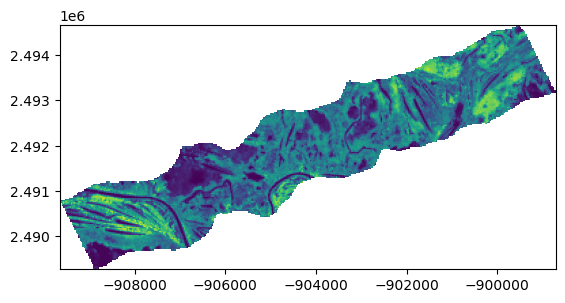

In [20]:
from rasterio.plot import show, show_hist

# Get dataset-specific s3 session
s3 = d['AWS_SESSION']

with rasterio.open(s3.open(s3_url, mode='rb')) as src:
    print(src.profile)
    show(src)